In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Capse_Planck`


In [2]:
# Pkg.add("Random")
# Pkg.add("LinearAlgebra")
# Pkg.add("Turing")
# Pkg.add("PosteriorStats")
# Pkg.add("Distributions")
# Pkg.add("PDMats")
# Pkg.add("LogExpFunctions")
# Pkg.add("Plots")
# Pkg.add("ArviZ")
# Pkg.add("HypothesisTests)

In [3]:
using Random
using LinearAlgebra
using Turing
using PosteriorStats
using Distributions
using PDMats
using LogExpFunctions
using Plots
using ArviZ

### Model Set Up

In [7]:
# Define the Turing model
@model function myfoo(SL, x)
    a ~ Uniform(-10, 10)
    b ~ Uniform(-10, 10)
    μ = a .* x .+ b
    S = Symmetric(SL * SL')
    # Multivariate Normal observation
    y ~ MvNormal(μ, PDMat(Cholesky(SL)))
    return y
end

# Setup synthetic data
Random.seed!(1234)
n = 100
R = rand(LKJCholesky(n, 1))
s = rand(filldist(truncated(TDist(7); lower=0), n))
SL = LowerTriangular(Diagonal(s) * R.L) + 0.2I
S = Symmetric(SL * SL')

x = Array(LinRange(-7, 7, n))
a_true = 1.0
b_true = -3.0
y = rand(MvNormal(a_true .* x .+ b_true, S))

100-element Vector{Float64}:
 -10.69527063150974
 -10.252760841752925
  -9.847087372275812
 -10.560420005646623
  -9.22761985592522
 -11.239895507038792
  -9.411066829212661
  -8.323260236398404
  -9.038885967956297
  -9.149043102923361
   ⋮
   5.139938339042853
   3.046206819297155
   4.7766993401301665
   2.9736980732526366
   2.7930330090236244
   4.246023435220193
   3.7467658593142277
   3.3706198309340896
   6.491405961258838

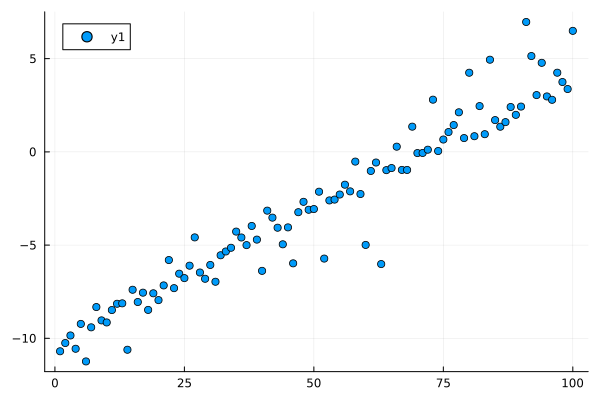

In [8]:
scatter(y)

In [9]:
# Sample from the model using 8 parallel chains
chns = sample(myfoo(SL, x) | (; y), NUTS(), MCMCThreads(), 2000, 8)

# Generate posterior predictions: stochastic realizations from the likelihood
y_pred = predict(myfoo(SL, x), chns)

┌ Warning: Only a single thread available: MCMC chains are not sampled in parallel
└ @ AbstractMCMC /Users/ethansmith/.julia/packages/AbstractMCMC/oqm6Y/src/sample.jl:544
Sampling (1 thread)   0%|                               |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.0015625
└ @ Turing.Inference /Users/ethansmith/.julia/packages/Turing/csgsG/src/mcmc/hmc.jl:223
Sampling (1 thread)   0%|▏                              |  ETA: 0:04:36
Sampling (1 thread)   1%|▎                              |  ETA: 0:02:27
Sampling (1 thread)   2%|▌                              |  ETA: 0:01:43
Sampling (1 thread)   2%|▋                              |  ETA: 0:01:22
Sampling (1 thread)   2%|▊                              |  ETA: 0:01:09
Sampling (1 thread)   3%|▉                              |  ETA: 0:01:00
Sampling (1 thread)   4%|█▏                             |  ETA: 0:00:53
Sampling (1 thread)   4%|█▎                             |  ETA: 0:00:48
Sampling (1 thread)   4%|█▍                    

Chains MCMC chain (2000×100×8 Array{Float64, 3}):

Iterations        = 1:1:2000
Number of chains  = 8
Samples per chain = 2000
parameters        = y[1], y[2], y[3], y[4], y[5], y[6], y[7], y[8], y[9], y[10], y[11], y[12], y[13], y[14], y[15], y[16], y[17], y[18], y[19], y[20], y[21], y[22], y[23], y[24], y[25], y[26], y[27], y[28], y[29], y[30], y[31], y[32], y[33], y[34], y[35], y[36], y[37], y[38], y[39], y[40], y[41], y[42], y[43], y[44], y[45], y[46], y[47], y[48], y[49], y[50], y[51], y[52], y[53], y[54], y[55], y[56], y[57], y[58], y[59], y[60], y[61], y[62], y[63], y[64], y[65], y[66], y[67], y[68], y[69], y[70], y[71], y[72], y[73], y[74], y[75], y[76], y[77], y[78], y[79], y[80], y[81], y[82], y[83], y[84], y[85], y[86], y[87], y[88], y[89], y[90], y[91], y[92], y[93], y[94], y[95], y[96], y[97], y[98], y[99], y[100]
internals         = 

Summary Statistics
  parameters       mean       std      mcse     ess_bulk     ess_tail      rha ⋯
      Symbol    Float64   Float64   Floa

### Marco's Manual LOO-PIT

In [ ]:
# Extract parameter samples
a_samples = chns[:a].data
b_samples = chns[:b].data

# Compute the mean array for all draws and chains (draws, chains, n)
μ_array = a_samples .* reshape(x, 1, 1, n) .+ b_samples

In [ ]:
S_pd = PDMat(Cholesky(SL))

# Instantiate distributions for each posterior slice
dists = map(μ -> MvNormal(μ, S_pd), eachslice(μ_array; dims=(1, 2)))

# Calculate pointwise conditional log-likelihoods
log_like = PosteriorStats.pointwise_conditional_loglikelihoods(y, dists)

In [ ]:
# Compute LOO to obtain smoothed importance weights
loo_res = loo(log_like)
log_weights = loo_res.psis_result.log_weights

In [ ]:
scatter(loo_res.pointwise.pareto_shape; marker=:+, markersize = 6, legend=false, linewidth=2)
hline!([0.5, 0.7], linestyle=:dot, color=:black)
hline!([1.0], linestyle=:solid, color=:black)

In [ ]:
# Clean predictions into (draws, chains, n)
y_pred_array = permutedims(y_pred[[Symbol("y[$i]") for i in 1:n]].value.data, (1, 3, 2))

pitvals_manual = zeros(n)
for i in 1:n
    y_pred_i = y_pred_array[:, :, i] 
    log_w_i = log_weights[:, :, i]
    
    # Identify which draws fall below the observation
    mask = y_pred_i .<= y[i]
    
    # Estimate the CDF as the sum of the weights of those draws
    pitvals_manual[i] = any(mask) ? exp(logsumexp(log_w_i[mask])) : 0.0
end

In [ ]:
scatter(pitvals_manual)

In [ ]:
histogram(pitvals_manual, bins=10)

In [ ]:
y_pred_array

In [ ]:
y_1_array = []
for i in 1:8
    y_1_array = append!(y_1_array, y_pred_array[:,i,1])
end

In [ ]:
histogram(y_1_array, normalize=:pdf, bins = 20, label="LOO Predictive")
vline!([y[1]], color=:red, linewidth=3, label = "Observed y1")

### Ethan's Manual LOO-PIT

### Comparison of Manual Approaches

In [ ]:
# println("Marco Manual LOO-PIT (first 5): ", round.(pitvals_manual[1:5], digits=4))
# println("Ethan Manual LOO-PIT (first 5): ", round.(PIT_Values[1:5], digits=4))

In [ ]:
# scatter(PIT_Values, pitvals_manual)
# plot!([0.0, 0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],[0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])

In [ ]:
# using HypothesisTests

# # Perform the KS test for the Monte Carlo version
# ks_test_marco = ExactOneSampleKSTest(pitvals_manual, Uniform(0, 1))

# # Perform the KS test for the Exact Analytic version
# ks_test_ethan = ExactOneSampleKSTest(PIT_Values, Uniform(0, 1))

# println("Marco LOO-PIT KS test p-value:    ", pvalue(ks_test_marco))
# println("Ethan LOO-PIT KS test p-value: ", pvalue(ks_test_ethan))